In [4]:
%pip install gymnasium[box2d]

starting training...
episode 10 | timesteps 6842 | avg reward (last 10): -93.98
episode 20 | timesteps 7857 | avg reward (last 10): -106.41
episode 30 | timesteps 13168 | avg reward (last 10): -95.01
episode 40 | timesteps 20060 | avg reward (last 10): -92.04
episode 50 | timesteps 23910 | avg reward (last 10): -92.95
episode 60 | timesteps 30201 | avg reward (last 10): -96.00
episode 70 | timesteps 36128 | avg reward (last 10): -122.95
episode 80 | timesteps 39480 | avg reward (last 10): -103.64
episode 90 | timesteps 43279 | avg reward (last 10): -99.05
episode 100 | timesteps 48781 | avg reward (last 10): -100.98
episode 110 | timesteps 52679 | avg reward (last 10): -94.27
episode 120 | timesteps 54983 | avg reward (last 10): -97.85
episode 130 | timesteps 61839 | avg reward (last 10): -87.96
episode 140 | timesteps 64465 | avg reward (last 10): -103.46
episode 150 | timesteps 69776 | avg reward (last 10): -88.48
episode 160 | timesteps 76592 | avg reward (last 10): -82.19
episode 1

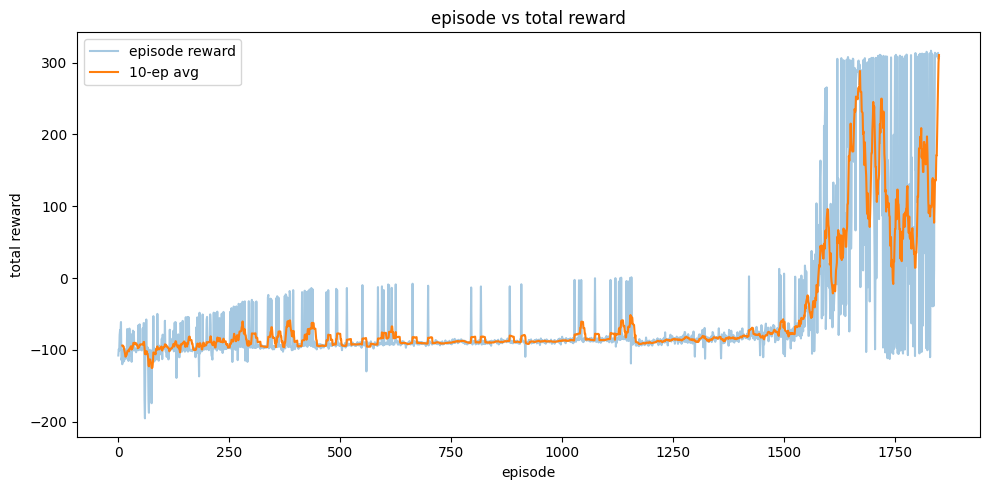

Streaming output truncated to the last 5000 lines.
  left contact: 0
  right contact: 0
  lidar[0..4]: [0.34, 0.34, 0.36, 0.38, 0.42]
  step reward: 0.308
step 688
  action (4 torques): [0.31, -0.32, -0.38, -0.22]
  hull angle (rad): 0.262
  hull angular velocity: -0.059
  horizontal velocity vx: 0.284
  left contact: 0
  right contact: 0
  lidar[0..4]: [0.34, 0.35, 0.36, 0.39, 0.42]
  step reward: 0.278
step 689
  action (4 torques): [0.33, -0.0, -0.35, -0.06]
  hull angle (rad): 0.241
  hull angular velocity: -0.042
  horizontal velocity vx: 0.285
  left contact: 0
  right contact: 0
  lidar[0..4]: [0.34, 0.35, 0.37, 0.39, 0.42]
  step reward: 0.271
step 690
  action (4 torques): [0.32, -0.17, -0.38, 0.23]
  hull angle (rad): 0.224
  hull angular velocity: -0.033
  horizontal velocity vx: 0.287
  left contact: 0
  right contact: 0
  lidar[0..4]: [0.35, 0.35, 0.37, 0.39, 0.42]
  step reward: 0.234
step 691
  action (4 torques): [-0.02, -0.08, -0.45, 0.14]
  hull angle (rad): 0.212
  h

In [6]:
import gymnasium as gym
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Normal

# hyperparameters
LR = 3e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
EPS_CLIP = 0.2
K_EPOCHS = 10
ENTROPY_COEF = 0.001
CRITIC_COEF = 0.5
MAX_STEPS = 1600
UPDATE_EVERY = 2048
TOTAL_TIMESTEPS = 1000000


class ActorCritic(nn.Module):
    def __init__(self, state_dim=24, action_dim=4):
        super().__init__()
        self.actor_base = nn.Sequential(
            nn.Linear(state_dim, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
        )
        self.actor_mean = nn.Linear(256, action_dim)
        # log_std as parameter, clamped during forward
        self.log_std = nn.Parameter(torch.full((action_dim,), -0.5))

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 1)
        )
        # orthogonal init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.actor_mean.weight, gain=0.01)

    def forward(self, state):
        x = self.actor_base(state)
        mean = self.actor_mean(x)
        std = self.log_std.clamp(-4, 0).exp().expand_as(mean)
        dist = Normal(mean, std)
        value = self.critic(state)
        return dist, value

    def get_action(self, state):
        state_t = torch.FloatTensor(state)
        with torch.no_grad():
            dist, value = self.forward(state_t)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        return action.numpy(), log_prob, value.squeeze()

    def evaluate(self, states, actions):
        dist, values = self.forward(states)
        log_probs = dist.log_prob(actions).sum(-1)
        entropy = dist.entropy().sum(-1)
        return log_probs, values.squeeze(-1), entropy


class RollingNorm:
    """running mean/var for reward normalization"""
    def __init__(self):
        self.mean = 0.0
        self.var = 1.0
        self.count = 1e-4

    def update(self, x):
        batch_mean = np.mean(x)
        batch_var = np.var(x)
        batch_count = len(x)
        total = self.count + batch_count
        self.mean = (self.count * self.mean + batch_count * batch_mean) / total
        self.var = (self.count * self.var + batch_count * batch_var +
                    (batch_mean - self.mean) ** 2 * self.count * batch_count / total) / total
        self.count = total

    def normalize(self, x):
        return np.clip(x / (np.sqrt(self.var) + 1e-8), -10, 10)


class Memory:
    def __init__(self):
        self.states, self.actions, self.rewards = [], [], []
        self.log_probs, self.dones, self.values = [], [], []

    def store(self, state, action, reward, log_prob, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.log_probs.append(log_prob)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.__init__()


def compute_gae(rewards, dones, values, gamma, lam):
    """generalized advantage estimation"""
    advantages = []
    gae = 0.0
    next_value = 0.0
    for r, d, v in zip(reversed(rewards), reversed(dones), reversed(values)):
        if d:
            next_value = 0.0
            gae = 0.0
        delta = r + gamma * next_value - v
        gae = delta + gamma * lam * gae
        advantages.insert(0, gae)
        next_value = v
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns


def ppo_update(model, optimizer, memory):
    states = torch.FloatTensor(np.array(memory.states))
    actions = torch.FloatTensor(np.array(memory.actions))
    old_log_probs = torch.stack(memory.log_probs).detach()
    values_np = [v.item() for v in memory.values]

    advantages, returns = compute_gae(
        memory.rewards, memory.dones, values_np, GAMMA, GAE_LAMBDA
    )
    advantages = torch.FloatTensor(advantages)
    returns = torch.FloatTensor(returns)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    n = len(states)
    batch_size = 64
    for _ in range(K_EPOCHS):
        idx = torch.randperm(n)
        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            log_probs, vals, entropy = model.evaluate(states[b], actions[b])
            ratio = torch.exp(log_probs - old_log_probs[b])
            adv_b = advantages[b]

            surr1 = ratio * adv_b
            surr2 = torch.clamp(ratio, 1 - EPS_CLIP, 1 + EPS_CLIP) * adv_b
            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = nn.MSELoss()(vals, returns[b])
            loss = actor_loss + CRITIC_COEF * critic_loss - ENTROPY_COEF * entropy.mean()

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()


def train():
    env = gym.make("BipedalWalker-v3")
    model = ActorCritic()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, eps=1e-5)
    memory = Memory()
    reward_norm = RollingNorm()

    episode_rewards = []
    total_timesteps = 0
    episode = 0

    print("starting training...")

    while total_timesteps < TOTAL_TIMESTEPS:
        state, _ = env.reset()
        ep_reward = 0
        episode += 1
        raw_ep_rewards = []

        for _ in range(MAX_STEPS):
            action, log_prob, value = model.get_action(state)
            action_clipped = np.clip(action, -1, 1)

            next_state, reward, terminated, truncated, _ = env.step(action_clipped)
            done = terminated or truncated

            raw_ep_rewards.append(reward)
            ep_reward += reward
            total_timesteps += 1

            # normalize reward before storing
            norm_r = reward_norm.normalize(np.array([reward]))[0]
            memory.store(state, action, norm_r, log_prob, done, value)
            state = next_state

            if total_timesteps % UPDATE_EVERY == 0:
                reward_norm.update(np.array(memory.rewards))
                ppo_update(model, optimizer, memory)
                memory.clear()

            if done:
                break

        episode_rewards.append(ep_reward)

        if episode % 10 == 0:
            avg = np.mean(episode_rewards[-10:])
            print(f"episode {episode} | timesteps {total_timesteps} | avg reward (last 10): {avg:.2f}")

        if len(episode_rewards) >= 10 and np.mean(episode_rewards[-10:]) >= 300:
            print("environment solved!")
            break

    env.close()
    torch.save(model.state_dict(), "ppo_bipedal.pth")
    print("model saved.")
    return model, episode_rewards


def test(model, num_episodes=5):
    env = gym.make("BipedalWalker-v3")
    model.eval()
    print("\n--- testing trained model ---")

    for ep in range(num_episodes):
        state, _ = env.reset()
        ep_reward = 0
        step = 0
        done = False
        print(f"\nepisode {ep + 1}")

        while not done and step < MAX_STEPS:
            with torch.no_grad():
                action, _, _ = model.get_action(state)
            action_clipped = np.clip(action, -1, 1)
            next_state, reward, terminated, truncated, _ = env.step(action_clipped)
            done = terminated or truncated

            print(f"step {step}")
            print(f"  action (4 torques): {[round(float(a), 2) for a in action_clipped]}")
            print(f"  hull angle (rad): {state[0]:.3f}")
            print(f"  hull angular velocity: {state[1]:.3f}")
            print(f"  horizontal velocity vx: {state[2]:.3f}")
            print(f"  left contact: {int(state[8])}")
            print(f"  right contact: {int(state[13])}")
            print(f"  lidar[0..4]: {[round(float(v), 2) for v in state[14:19]]}")
            print(f"  step reward: {reward:.3f}")

            state = next_state
            ep_reward += reward
            step += 1

        print(f"total reward episode {ep + 1}: {ep_reward:.2f}")

    env.close()


def plot_rewards(episode_rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(episode_rewards, alpha=0.4, label="episode reward")
    window = 10
    if len(episode_rewards) >= window:
        moving_avg = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')
        plt.plot(range(window - 1, len(episode_rewards)), moving_avg, label=f"{window}-ep avg")
    plt.xlabel("episode")
    plt.ylabel("total reward")
    plt.title("episode vs total reward")
    plt.legend()
    plt.tight_layout()
    plt.savefig("reward_plot.png", dpi=150)
    plt.show()
    print("plot saved as reward_plot.png")


if __name__ == "__main__":
    model, episode_rewards = train()
    plot_rewards(episode_rewards)
    test(model, num_episodes=5)